In [1]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools as itt
from tqdm import tqdm
import gc

import sys
sys.path.insert(0, '..') # TODO: this is probably not the right way to do this

from src.datasets import NetworksDataset, TEPsDataset
from src.automata import LLNA
from src.simulation import *
from src.analysis import jacobian, jacobian_ECA, calculate_Yt, lyapunov_spectrum

%load_ext autoreload
%autoreload 2

In [2]:
sys.path.insert(0, '../src/network_analysis/lib') 
from analytics import DataPool, Report

datapool = DataPool()
datapool.load('../data/info', n=True, m=True, r=True)

../data/info/flags.dat loaded in memory
../data/info/networks.dat loaded in memory
../data/info/measures.dat loaded in memory
../data/info/results.dat loaded in memory


Trajectory difference depends on the original trajectory and its disturbed version. One way to study it it by disturbing once, at the begining (results in the dataset with `disturb_freq="single"`), another way is by perturbing the original trajectory multiple times, on every time step (`disturb_freq="multi"`).

If the disturb occurs only once, then each trajectory will evolve independly. The damage can spread (growing) of vanish (shrinking). The amount of damage in the configuration space generated by a single unitary defect is given by the divergence of the trajectories along time.

$$ \mathbf{x}^t = \Phi^t(\mathbf{x}^0) $$

$$ \Delta\mathbf{x}^t = \mathbf{x}^t \oplus \Phi^t(\mathbf{x}^0 \oplus \delta\mathbf{x}^0) $$

Another way to approach this problem is by disturbing the main trajectory at each time step to see how it is sensible to perturbations. Note how the equation below differs from the one above: instead of disturbing at $t=0$ and evolving for $t$ time steps, we evolve for $t-1$ time steps, disturb and then evolve one more step.

$$ \Delta\mathbf{x}^t = \mathbf{x}^t \oplus \Phi(\mathbf{x}^{t-1} \oplus \delta\mathbf{x}^{t-1}) $$

This approach will no longer show any big (possibly infinite) divergence in the configuration space, but allow us to track it in the tangent space. First, lets define the dependence of a given node $i$ related to a perturbation on node $j$ at time $t$.

$$
\frac{\partial x(v_i,t+1)}{\partial x(v_j,t)}
 = \left.\frac{\partial \Phi_i}{\partial x_j}\right|_t
 = \Phi_i(\mathbf{x}^t) \oplus \Phi_i(\mathbf{x}^t \oplus \hat{e}_j)
$$

This is the same as calculate the difference of the trajectories for node $i$ at time step $t+1$ due to an unitary disturb at node $j$ at time step $t$.

$$
\frac{\partial x(v_i,t+1)}{\partial x(v_j,t)}
 = \left.\Delta{x}^{t+1}_i\right|_{\delta\mathbf{x}^t = \hat{e}_j}
$$

The jacobian matrix allows us to keep track of all these possible divergences on the tangent space.

$$
\mathbf{J}(\mathbf{x}^t) = \left[ \left.\frac{\partial \Phi_i}{\partial x_j}\right|_t \right]
 = \begin{bmatrix}
    \left.\frac{\partial \Phi_1}{\partial x_1}\right|_t & \dots &
    \left.\frac{\partial \Phi_1}{\partial x_N}\right|_t \\[5pt]
    %
    \vdots & \ddots & \cdots \\[5pt]
    %
    \left.\frac{\partial \Phi_N}{\partial x_1}\right|_t & \dots &
    \left.\frac{\partial \Phi_N}{\partial x_N}\right|_t \\[5pt]
\end{bmatrix}
$$

Also, if we make a matrix of all unitary perturbations (unitary sphere) and linearize the system dynamics by the jacobian, we can approximate the spread of the disturbs in the tangent space.

$$ \mathbf{Y}^0 = \left[ \hat{e}_i \right] = \mathbf{I}_N $$

$$ \mathbf{Y}^{t} = \mathbf{J}(\mathbf{x}^{t-1}) \mathbf{Y}^{t-1} $$

$$ \mathbf{Y}^t = \left(\prod_{\tau=0}^{t-1} \mathbf{J}(\mathbf{x}^{t-\tau})\right) \mathbf{Y}^0 $$

The Lyapunov exponents (for the tangent space) can be calculated as follow, with $\Lambda_i^t$ being the singular values of the matrix $\mathbf{Y}^t$.

$$ \Lambda_i = \lim_{t \to \infty} \frac{1}{t} \ln(\Lambda_i^t), \quad i \in \{1, \dots N\} $$

# 1) Amount of Defects

First, let's look at the damage propagation in the configuration space.

## 1.1) Looking at one network

Here we fix the rule, the network and the initial configuration. The focus is on how to explore the time series of the trajectories -- original and perturbed ones.

We refer to $\Delta\mathbf{x}^t$ as `Xd`, but note that the variable `Xd` has more "dimensions":

- the first represents the origint of the perturbation;
- the second is the time axis;
- the third is the configuration of the nodes.

Therefore, the value `Xd[n_j, t, n_i]` denotes the state of node $n_i$ at time step $t$ and due to an initial disturb in node $n_j$, which equals to $\Delta{}x^t_i$ given $\delta\mathbf{x}^0 = \hat{e}_j$.

**IMPORTANT**

As we will progressing, it will be clear that is not feasible to store all the time series on memory, so we will aggregate the time series in some ways.

The first approach is intended to reveal the impact of each node as the source of the damage, and how it will spreads the perturbation to the entire network on average. So, instead of looking at the individual damage, we'll take the mean along the last axis of `Xd`. Let `Xpercent[n_j, t]` be the proportion of nodes disturbed.

Other approach shall be usefull as well. Some ideas to explore:

- how a specific node is affected on average, regardless of the source of damage?
- how the damage spreads along time, normalized by the total amount nodes reachable at that time instead of the size of the entire network?

In [9]:
# `defect_freq="single"` refers to a unitary disturb made only in the first time step
dataset = TEPsDataset(path='../data/teps', rule='R2B1S2', defect_freq='single', transform=np.array, cached=False)

In [10]:
# shape = [num_inits, num_trajectories, time_steps, num_nodes]
# num_scenarios = 1 (original) + N unitary defects (one per node)
dataset[0].shape

(5, 51, 51, 50)

In [11]:
init_conf = 0
X_all = dataset[50][init_conf]
Xo = X_all[0]        # original trajectory
Xp = X_all[1:]       # perturbed trajectories
Xo.shape, Xp.shape

((51, 50), (50, 51, 50))

In [12]:
# the delta at t=0 is the identity
# after more time steps, the initial perturbation
# can propagate or vanish
Xd = np.abs(Xp - Xo) # abs. difference (delta)
Xd[:,0,:]

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]])

In [13]:
Xpercent = Xd.mean(-1)
Xpercent.shape

(50, 51)

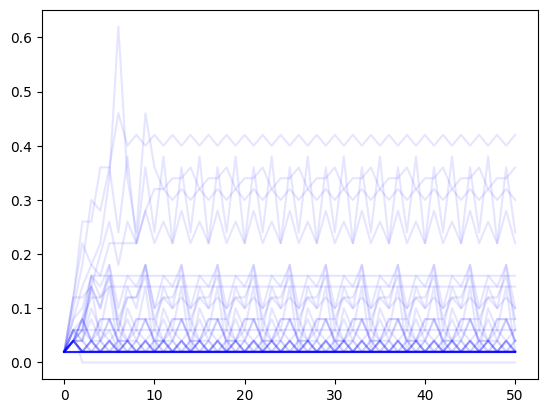

In [14]:
_ = plt.plot(Xpercent.T, c='blue', alpha=0.1)

In [9]:
df = pd.concat([
    pd.DataFrame({
        'node': i,
        'time': np.arange(len(x)),
        'percent': x
    })
    for i, x in enumerate(Xpercent)
])
df

,node,time,percent
0,0,0,0.02
1,0,1,0.04
2,0,2,0.02
3,0,3,0.04
4,0,4,0.02
...,...,...,...
46,49,46,0.02
47,49,47,0.02
48,49,48,0.02
49,49,49,0.02


In [10]:
sns.set_palette('Set2')
sns.set_style('darkgrid')

<Axes: xlabel='time', ylabel='percent'>

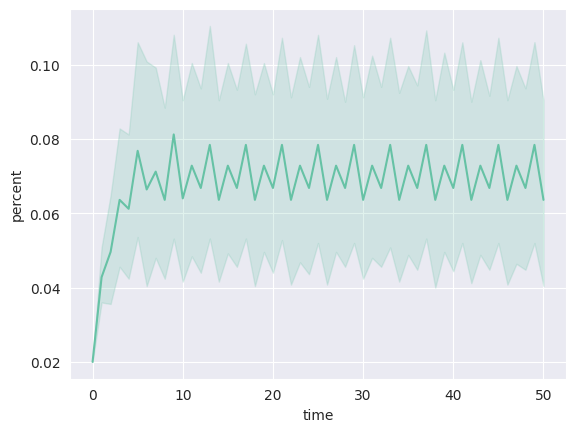

In [11]:
sns.lineplot(
    df,
    x = 'time',
    y = 'percent',
    errorbar = 'ci',
)

## 1.2) Looking at multiple initial configurations

Here we will expand the amount of initial configurations, keeping the rule and the network fixed. This is necessary to extract the average behavior of the automaton on that topology.

In [28]:
ntw_id = 150
X_all = dataset[ntw_id]
Xo = X_all[:, 0]        # original trajectory
Xp = X_all[:, 1:]       # perturbed trajectories
Xo.shape, Xp.shape

((5, 51, 100), (5, 100, 51, 100))

In [29]:
Xd = np.stack([ np.abs(Xp[i] - Xo[i]) for i in range(len(Xp)) ])
Xd.shape

(5, 100, 51, 100)

In [30]:
Xpercent = Xd.mean(-1)
Xpercent.shape

(5, 100, 51)

In [73]:
t = np.arange(Xpercent.shape[-1])
df = pd.DataFrame({ 'time_step': [t]*len(Xpercent), 'disturb_percent': [ *Xpercent ] })
df

,time_step,disturb_percent
0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.01, 0.03, 0.07, 0.1, 0.18, 0.2, 0.18, 0.21..."
1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.01, 0.04, 0.1, 0.1, 0.13, 0.14, 0.12, 0.13..."
2,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.01, 0.05, 0.23, 0.35, 0.42, 0.36, 0.39, 0...."
3,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.01, 0.02, 0.12, 0.16, 0.23, 0.3, 0.31, 0.3..."
4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.01, 0.06, 0.18, 0.27, 0.29, 0.31, 0.31, 0...."


In [74]:
df = df.explode('disturb_percent')
df.reset_index(drop=False, inplace=True, names='init')
df

,init,time_step,disturb_percent
0,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.01, 0.03, 0.07, 0.1, 0.18, 0.2, 0.18, 0.21,..."
1,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.01, 0.09, 0.34, 0.39, 0.49, 0.43, 0.44, 0.4..."
2,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.01, 0.09, 0.18, 0.34, 0.35, 0.38, 0.37, 0.3..."
3,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.01, 0.08, 0.21, 0.35, 0.33, 0.44, 0.42, 0.4..."
4,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.01, 0.14, 0.36, 0.5, 0.48, 0.49, 0.48, 0.48..."
...,...,...,...
495,4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.01, 0.02, 0.05, 0.09, 0.16, 0.3, 0.26, 0.3,..."
496,4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.01, 0.02, 0.05, 0.13, 0.26, 0.29, 0.26, 0.2..."
497,4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.01, 0.02, 0.06, 0.25, 0.35, 0.3, 0.32, 0.33..."
498,4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.01, 0.05, 0.11, 0.33, 0.38, 0.36, 0.37, 0.3..."


Note how the number of rows is increasing fast. We have a total of $N \times C \times T$ rows, beeing:

- $N = 100$ the number of nodes in this selected network;
- $C = 5$ the number of initial configurations;
- $T = 51$ the number of time steps (initial, $t=0$, plus 50 more);

In [75]:
df = df.explode(['disturb_percent', 'time_step'])
df.reset_index(drop=False, inplace=True, names='node')
df

,node,init,time_step,disturb_percent
0,0,0,0,0.01
1,0,0,1,0.03
2,0,0,2,0.07
3,0,0,3,0.1
4,0,0,4,0.18
...,...,...,...,...
25495,499,4,46,0.29
25496,499,4,47,0.27
25497,499,4,48,0.28
25498,499,4,49,0.28


Also note how each initial configuration lead to different average behaviors. They have similar shape, converges to distinct percentages. In addition, the overshoot seems to happen often, but not every time.

<Axes: xlabel='time_step', ylabel='disturb_percent'>

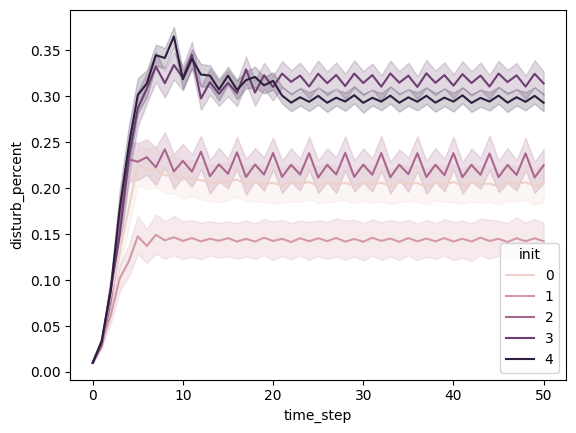

In [76]:
sns.lineplot(
    df,
    x = 'time_step',
    y = 'disturb_percent',
    hue = 'init',
    errorbar = 'ci',
)

## 1.3) Looking at multiple networks

Now let's look to the behavior of multiple networks and how we can relate them with their structural properties. To simplify, the automaton rule will keep the same and we'll consider only one initial configuration per network again.

To aid in this step, we need to import the tables containing some complex network measures, calculated with the generation of the networks. With these tables, we can generate tabular reports -- node-level or graph-level -- of the applied measures.

In [13]:
datapool.networks

,collection,dataset,label,N,M,K,abbr,graph,source
network_id,,,,,,,,,
0,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",<containers.GraphAPI object at 0x7fe1e97c86d0>,network_000000.txt
1,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_799951551",<containers.GraphAPI object at 0x7fe1e97c8790>,network_000001.txt
2,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_2063321439",<containers.GraphAPI object at 0x7fe1e97c8d30>,network_000002.txt
3,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_1440823959",<containers.GraphAPI object at 0x7fe1e97c8d90>,network_000003.txt
4,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_700066056",<containers.GraphAPI object at 0x7fe1e97c8df0>,network_000004.txt
...,...,...,...,...,...,...,...,...,...
235,robustness,toy,BA,250,990,NaN,"BA({'n': 250, 'm': 4, 'power': 1})_224915926",<containers.GraphAPI object at 0x7fe1e8fc87c0>,network_000235.txt
236,robustness,toy,BA,250,990,NaN,"BA({'n': 250, 'm': 4, 'power': 1})_1779759265",<containers.GraphAPI object at 0x7fe1e8fc8850>,network_000236.txt
237,robustness,toy,BA,250,990,NaN,"BA({'n': 250, 'm': 4, 'power': 1})_1584961966",<containers.GraphAPI object at 0x7fe1e8fc88e0>,network_000237.txt


Sometimes, the graph-level measures consist on a statistical moment of node-level measure.

In [14]:
m_mask = (datapool.measures['scope']=='graph')
rep_g = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False)
rep_g = pd.merge(datapool.networks[['abbr']], rep_g, on='abbr')
rep_g

,abbr,diam,avg_gdist,effic,hmean_gdist,max_deg,avg_deg,var_deg,skw_deg,krt_deg,avg_cc,avg_bc,cpd,p_deg_enrg,p_deg_entr,q_deg_entr
0,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",12,4.7344,0.263493,3.795161,8,1.96,2.5584,8.547072,44.942968,0.0,93.86,655.244898,1.056238,1.217547,1.663515
1,"BA({'n': 50, 'm': 1, 'power': 1})_799951551",13,4.7832,0.26638,3.754038,9,1.96,2.9584,12.555072,80.780408,0.0,95.08,745.836735,1.096447,1.251228,1.819857
2,"BA({'n': 50, 'm': 1, 'power': 1})_2063321439",11,4.4368,0.274565,3.642123,10,1.96,2.5584,11.907072,90.600568,0.0,86.42,845.489796,1.035805,1.251861,1.674794
3,"BA({'n': 50, 'm': 1, 'power': 1})_1440823959",7,3.524,0.32165,3.108974,13,1.96,5.6784,53.681472,595.49452,0.0,63.6,926.938776,1.30307,1.065205,1.484478
4,"BA({'n': 50, 'm': 1, 'power': 1})_700066056",8,3.3664,0.33491,2.985873,18,1.96,7.1984,89.863872,1376.069112,0.0,59.66,922.795918,1.411364,1.057209,1.751871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,"BA({'n': 250, 'm': 4, 'power': 1})_224915926",5,2.725504,0.393185,2.543332,56,7.92,42.5376,942.265536,33009.171487,0.173642,216.188,4815.234223,12.134496,2.319957,2.942858
236,"BA({'n': 250, 'm': 4, 'power': 1})_1779759265",4,2.720768,0.393725,2.539842,50,7.92,43.7216,918.189696,29133.277752,0.185811,215.596,3578.925998,12.199054,2.314909,2.994562
237,"BA({'n': 250, 'm': 4, 'power': 1})_1584961966",5,2.76288,0.388615,2.573241,41,7.92,37.4976,687.687936,18881.948191,0.14012,220.86,2874.775399,11.996135,2.330897,2.880221
238,"BA({'n': 250, 'm': 4, 'power': 1})_420171985",4,2.712064,0.395005,2.531611,53,7.92,45.4656,1089.776256,39661.446482,0.154256,214.508,4109.545958,12.217222,2.264026,2.8912


In [15]:
m_mask = (datapool.measures['scope']=='vertex')
rep_v = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False)
rep_v = rep_v.reset_index()
rep_v = pd.merge(datapool.networks[['abbr']], rep_v, on='abbr')
rep_v

,abbr,dataset,vertex,deg,qt_tri,cc,bc,pagerank
0,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,0,3,3.0,0.0,140.0,0.029268
1,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,1,6,15.0,0.0,730.0,0.052653
2,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,2,6,15.0,0.0,712.0,0.05432
3,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,3,3,3.0,0.0,615.0,0.027441
4,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,4,6,15.0,0.0,272.0,0.057424
...,...,...,...,...,...,...,...,...
31995,"BA({'n': 250, 'm': 4, 'power': 1})_384038923",toy,245,4,6.0,0.333333,14.607991,0.002233
31996,"BA({'n': 250, 'm': 4, 'power': 1})_384038923",toy,246,4,6.0,0.0,20.773805,0.002278
31997,"BA({'n': 250, 'm': 4, 'power': 1})_384038923",toy,247,4,6.0,0.333333,42.002795,0.002319
31998,"BA({'n': 250, 'm': 4, 'power': 1})_384038923",toy,248,4,6.0,0.0,17.829913,0.00239


The normal way to handle this data structure is to register a function as a measure in the datapool and apply it to a subset of networks, but as we already have the results stored on disk, we can register the results directly.

Here we'll append the results in the tabular report. Later we'll append them in the datapool itself.

In [16]:
def disturb_diff(ds, init):
    for graph_id, X in enumerate(ds):
        X_all = X[init]
        Xo = X_all[0]
        Xp = X_all[1:]
        Xd = np.abs(Xp - Xo)
        yield (graph_id, Xd)
#

def network_properties(net_id, *reports):
    g_prop = reports[0].loc[net_id]
    g_name = g_prop['abbr']
    n_mask = (reports[1]['abbr'] == g_name)
    n_prop = reports[1][n_mask]
    return g_prop, n_prop
#

df = []
for i, Xpercent in tqdm(disturb_diff(dataset, 0), total=len(dataset)):
    g_prop, n_prop = network_properties(i, rep_g, rep_v)
    for j, x in enumerate(Xpercent):
        df.append(pd.DataFrame({
            'network': i,
            'node': j,
            'time': np.arange(len(x)),
            'amount of disturbed nodes': x.sum(-1),
            'percent of disturbed nodes': x.mean(-1),
            'network diameter': g_prop['diam'],
            'network efficiency': g_prop['effic'],
            'network mean distance': g_prop['avg_gdist'],
            'network mean degree': g_prop['avg_deg'],
            'source node degree': n_prop['deg'].values[j],
            'source node degree (norm)': n_prop['deg'].values[j] / x.shape[-1],
            'source node clustering coef.': n_prop['cc'].values[j] / 2,
        }))
df = pd.concat(df, ignore_index=True)
df

100%|██████████████████████████████████████████████████████████| 240/240 [00:24<00:00,  9.64it/s]


,network,node,time,amount of disturbed nodes,percent of disturbed nodes,network diameter,network efficiency,network mean distance,network mean degree,source node degree,source node degree (norm),source node clustering coef.
0,0,0,0,1,0.020,12,0.263493,4.734400,1.96,3,0.060,0.0
1,0,0,1,3,0.060,12,0.263493,4.734400,1.96,3,0.060,0.0
2,0,0,2,2,0.040,12,0.263493,4.734400,1.96,3,0.060,0.0
3,0,0,3,1,0.020,12,0.263493,4.734400,1.96,3,0.060,0.0
4,0,0,4,2,0.040,12,0.263493,4.734400,1.96,3,0.060,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1631995,239,249,46,12,0.048,5,0.393223,2.726144,7.92,4,0.016,0.0
1631996,239,249,47,16,0.064,5,0.393223,2.726144,7.92,4,0.016,0.0
1631997,239,249,48,12,0.048,5,0.393223,2.726144,7.92,4,0.016,0.0
1631998,239,249,49,17,0.068,5,0.393223,2.726144,7.92,4,0.016,0.0


Before analyzing the disturb progression, it's advised to remove the outliers. Here, considering the network diameter a feature to segment the data, we'll consider only networks whose diameter appears in at least 5 different networks.

In [17]:
diams = rep_g.groupby('diam').count()[['abbr']]
diams

,abbr
diam,
3,11
4,61
5,75
6,23
7,12
8,1
9,6
10,8
11,8


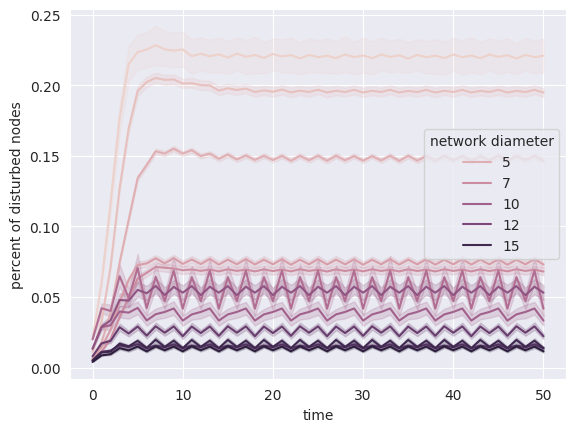

In [18]:
representative = diams[(diams['abbr'] >= 5)].index
mask = (df['network diameter'].isin(representative))
sns.lineplot(
    df[mask],
    x = 'time',
    y = 'percent of disturbed nodes',
    hue = 'network diameter',
    errorbar = 'ci',
)
plt.show()

Now we'll segment by the node clustering coefficient ($cc$). As the $cc$ is not discrete but continuous, another step is required. The values are rounded and grouped into five ranges between 0 and 1.

In [19]:
sns.color_palette('magma_r', 5)

[(0.997077, 0.690088, 0.471811),
 (0.944006, 0.377643, 0.365136),
 (0.709962, 0.212797, 0.477201),
 (0.445163, 0.122724, 0.506901),
 (0.171713, 0.067305, 0.370771)]

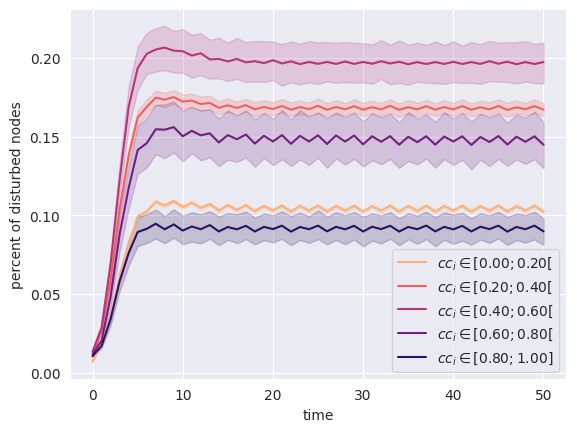

In [24]:
col = 'source node clustering coef.'
cc_min = df[col].min()
cc_max = df[col].max()
step = (cc_max - cc_min) / 5
colors = sns.color_palette('magma_r', 5)
for cc, cl in zip(np.arange(cc_min, cc_max, step), colors):
    if cc+step < cc_max:
        mask = (
            (df[col]>=cc) &
            (df[col]<cc+step)
        )
        sns.lineplot(
            df[mask],
            x = 'time',
            y = 'percent of disturbed nodes',
            errorbar = 'ci',
            label = fr'$cc_i \in [{cc:.2f}; {cc+step:.2f}[$',
            color = cl,
        )
    else:
        mask = (
            (df[col]>=cc) &
            (df[col]<=cc+step)
        )
        sns.lineplot(
            df[mask],
            x = 'time',
            y = 'percent of disturbed nodes',
            errorbar = 'ci',
            label = fr'$cc_i \in [{cc:.2f}; {cc+step:.2f}]$',
            color = cl,
        )

Now we'll take a new measure along the time axis. First, lets take the average of the disturb on the last 10 time steps. This is similar to the steady-state value of the dynamical system represented by the automaton and the network.

In [25]:
df_aux = df[ df['time']>10 ]
df_aux = df_aux[ [ col for col in df_aux.columns if col != 'time' ] ]
df_aux = df_aux.groupby(['network', 'node']).mean().reset_index()
df_aux

,network,node,amount of disturbed nodes,percent of disturbed nodes,network diameter,network efficiency,network mean distance,network mean degree,source node degree,source node degree (norm),source node clustering coef.
0,0,0,1.500,0.0300,12.0,0.263493,4.734400,1.96,3.0,0.060,0.000000
1,0,1,13.500,0.2700,12.0,0.263493,4.734400,1.96,6.0,0.120,0.000000
2,0,2,14.500,0.2900,12.0,0.263493,4.734400,1.96,6.0,0.120,0.000000
3,0,3,5.000,0.1000,12.0,0.263493,4.734400,1.96,3.0,0.060,0.000000
4,0,4,11.000,0.2200,12.0,0.263493,4.734400,1.96,6.0,0.120,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
31995,239,245,50.575,0.2023,5.0,0.393223,2.726144,7.92,4.0,0.016,0.166667
31996,239,246,77.200,0.3088,5.0,0.393223,2.726144,7.92,4.0,0.016,0.000000
31997,239,247,91.600,0.3664,5.0,0.393223,2.726144,7.92,4.0,0.016,0.166667
31998,239,248,49.825,0.1993,5.0,0.393223,2.726144,7.92,4.0,0.016,0.000000


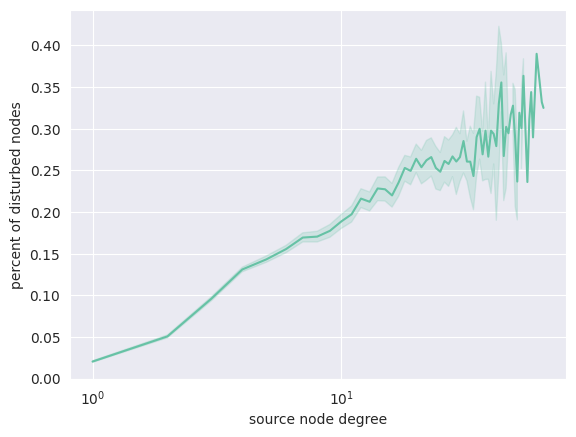

In [26]:
sns.lineplot(
    df_aux,
    x = 'source node degree',
    y = 'percent of disturbed nodes',
    #hue = 'network diameter',
    errorbar = 'ci',
)
plt.xscale('log')

## 1.4) Looking at multiple inits, networks and rules

Finally, let's consider all the available data. For this we'll take an entire family of LLNA (for instance, $R = 2$), all created networks and their trajectories for all random initial configurations.

First, let's insert all TEPs and its respective automata inside the datapool to make the analysis easier.

In [3]:
items = os.scandir('../data/teps')
is_compressed = lambda item: ('zip' in item.name or 'tar.xz' in item.name)
get_names = lambda item: item.name.split('.')[0]
rule_names = sorted(set(map(get_names, filter(is_compressed, items))))
rule_names

['R2B0S0',
 'R2B0S1',
 'R2B0S2',
 'R2B0S3',
 'R2B1S0',
 'R2B1S1',
 'R2B1S2',
 'R2B1S3',
 'R2B2S0',
 'R2B2S1',
 'R2B2S2',
 'R2B2S3',
 'R2B3S0',
 'R2B3S1',
 'R2B3S2',
 'R2B3S3']

In [4]:
datapool.load('../data/info', n=True, m=True, r=True)

../data/info/flags.dat loaded in memory
../data/info/networks.dat loaded in memory
../data/info/measures.dat loaded in memory
../data/info/results.dat loaded in memory


Due to the way this data structure works, each automaton is stores as a different "measure", as the intended behavior is to get the report table by the cartesian product of the networks table and the measures table, consolidated by the results table, and then pivot it to expand list-like results (i.e. the ones at node-level).

In [5]:
measures = pd.DataFrame({
    'name': [ f'rule {nm} defect propagation' for nm in rule_names ],
    'varname': [ f'llna_{nm}_defects' for nm in rule_names ],
    'symbol': [ f'LLNA*(V|{nm},T=50)' for nm in rule_names ],
    'scope': 'vertex',
    'function': None,
    'dependence': None,
    'default': None,
    'category': 'defect tracing'
})
datapool.update(m=measures)
datapool.measures.tail()

,name,varname,symbol,scope,category,function,dependence,default
measure_id,,,,,,,,
35,rule R2B2S3 defect propagation,llna_R2B2S3_defects,"LLNA*(V|R2B2S3,T=50)",vertex,defect tracing,None,None,None
36,rule R2B3S0 defect propagation,llna_R2B3S0_defects,"LLNA*(V|R2B3S0,T=50)",vertex,defect tracing,None,None,None
37,rule R2B3S1 defect propagation,llna_R2B3S1_defects,"LLNA*(V|R2B3S1,T=50)",vertex,defect tracing,None,None,None
38,rule R2B3S2 defect propagation,llna_R2B3S2_defects,"LLNA*(V|R2B3S2,T=50)",vertex,defect tracing,None,None,None
39,rule R2B3S3 defect propagation,llna_R2B3S3_defects,"LLNA*(V|R2B3S3,T=50)",vertex,defect tracing,None,None,None


Here we open each dataset and load the aggregated values on memory. It can take some time as the datasets are compressed. To not consume too much memory, the time axis is cutted: only the first `max_t` steps after $t=0$ are taken into account. Also, note how the "dimensions" are permuted (described in the comment lines).

In [ ]:
max_t = 30
n_id = datapool.networks.index
m_mask = (
    (datapool.measures['category'] == 'defect tracing') & 
    (datapool.measures['scope'] == 'vertex')
)
total_defect = lambda X: np.abs(X[1:] - X[0]).mean(-1).astype(np.float32)
broadcast = lambda f, *args: np.stack([ f(*args_i) for args_i in zip(*args) ])

for m_id, row in tqdm(datapool.measures[m_mask].iterrows(), total=len(rule_names)):
    rname = row['varname'].split('_')[1]
    dataset = TEPsDataset(path='../data/teps', rule=rname, defect_freq='single', transform=np.array, cached=False)
    # original shape = (num_inits X num_trajectories X time_steps+1 X num_nodes)
    # adjusted shape = (num_trajectories-1 X num_inits X max_t+1)
    #                = (num_nodes X num_inits X max_t+1)
    results = pd.DataFrame({
        'network_id': n_id,
        'measure_id': m_id,
        'value' : [ broadcast(total_defect, teps)[..., :max_t+1].transpose(1, 0, 2) for teps in dataset ],
        'time': 0
    })
    del dataset
    datapool.update(r=results)

In [7]:
Xd = results.iloc[0]['value']
Xd.shape

(50, 5, 31)

In [8]:
def nth_kw_with(part, n, **kwargs):
    keys = list(filter(lambda key: part in key, kwargs.keys()))
    return kwargs[ keys[n] ]

def defect_peak_time(G, **kwargs):
    Xd = nth_kw_with('_defects', 0, **kwargs)
    return np.argmax(Xd, -1)

def defect_stationary_value(G, **kwargs):
    Xd = nth_kw_with('_defects', 0, **kwargs)
    tp = nth_kw_with('_tpeak', 0, **kwargs)
    #tf = min([ -2*tp, -1 ]) if (tp <= len(Xd)/3.0) else tp
    tf = -5
    return Xd[..., tf:].mean(-1)

measures = pd.DataFrame({
    'name': [ f'peak time of rule {nm} defects' for nm in rule_names ],
    'varname': [ f'llna_{nm}_tpeak' for nm in rule_names ],
    'symbol': [ f'argmax(LLNA*(V|{nm},T=50))' for nm in rule_names ],
    'scope': 'vertex',
    'function': defect_peak_time,
    'dependence': [ [f'rule {nm} defect propagation'] for nm in rule_names ],
    'default': None,
    'category': 'defect tracing'
})
datapool.update(m=measures)
m_mask = (datapool.measures['varname'].isin(measures['varname']))
datapool.update(r=datapool.evaluate(measure_subset=m_mask, log_info=True))

measures = pd.DataFrame({
    'name': [ f'steady-state of rule {nm} defects' for nm in rule_names ],
    'varname': [ f'llna_{nm}_xsteady' for nm in rule_names ],
    'symbol': [ f'Xd(LLNA*(V|{nm},T=50)|t=infty)' for nm in rule_names ],
    'scope': 'vertex',
    'function': defect_stationary_value,
    'dependence': [ [
        f'rule {nm} defect propagation',
        f'peak time of rule {nm} defects'
    ] for nm in rule_names ],
    'default': None,
    'category': 'defect tracing'
})
datapool.update(m=measures)
m_mask = (datapool.measures['varname'].isin(measures['varname']))
datapool.update(r=datapool.evaluate(measure_subset=m_mask, log_info=True))

Network 240/240: 100%|█████████████████████| 3840/3840 [00:26<00:00, 147.61it/s]


In [9]:
datapool.save('../data/info/temp', m=True, r=True)

../data/info/temp/flags.dat saved in disk
../data/info/temp/measures.dat saved in disk
../data/info/temp/results.dat saved in disk


In [11]:
datapool.load('../data/info', n=True)
datapool.load('../data/info/temp', m=True, r=True, strict=True)
gc.collect()

../data/info/flags.dat loaded in memory
../data/info/networks.dat loaded in memory
../data/info/temp/measures.dat loaded in memory
../data/info/temp/results.dat loaded in memory


0

Then, let's generate 3 table-like reports with the structural measures at (i) graph-level and (ii) node-level, and (iii) the trajectories of the automata with disturbs. Those tables will be filtered and joined for the next plots.

In [12]:
# get relevant data
m_mask = (datapool.measures['scope']=='graph')
df_ntw = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False).infer_objects()
df_ntw.reset_index(drop=False, inplace=True)
del df_ntw['dataset']

# adjust columns
df_ntw.rename(columns={ col: f'ntw_{col}' for col in df_ntw.columns[1:] }, inplace=True)
df_ntw.columns.name = ''

# show a preview
print('shape =', df_ntw.shape)
df_ntw.head()

shape = (240, 16)


,abbr,ntw_diam,ntw_avg_gdist,ntw_effic,ntw_hmean_gdist,ntw_max_deg,ntw_avg_deg,ntw_var_deg,ntw_skw_deg,ntw_krt_deg,ntw_avg_cc,ntw_avg_bc,ntw_cpd,ntw_p_deg_enrg,ntw_p_deg_entr,ntw_q_deg_entr
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",12,5.3088,0.223358,4.477112,9,1.98,2.7596,10.765584,65.894624,0.0,215.94,3499.050505,1.091826,1.296472,1.863004
1,"BA({'n': 100, 'm': 1, 'power': 1})_112366346",10,4.6358,0.253175,3.949843,17,1.98,5.2396,52.194384,689.202976,0.0,182.29,3706.777778,1.281153,1.157330,1.834840
2,"BA({'n': 100, 'm': 1, 'power': 1})_1144810539",14,6.0124,0.210254,4.756150,14,1.98,3.6996,24.501984,250.571280,0.0,251.12,3701.898990,1.170811,1.251785,1.913509
3,"BA({'n': 100, 'm': 1, 'power': 1})_1179489287",10,4.4454,0.260975,3.831786,23,1.98,5.9196,95.855184,1969.334208,0.0,172.77,4087.101010,1.256309,1.226395,1.786584
4,"BA({'n': 100, 'm': 1, 'power': 1})_1355993402",15,5.8426,0.213959,4.673798,12,1.98,2.7996,14.547984,122.277120,0.0,242.63,3334.717172,1.074294,1.300308,1.843396


In [13]:
# get relevant data
m_mask = (datapool.measures['scope']=='vertex')
df_aux = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False).infer_objects()
df_aux.reset_index(drop=False, inplace=True)
cols = [ col for col in df_aux.columns if col != 'dataset' and not col.startswith('llna') ]
df_vtx = df_aux[cols].copy()

# adjust columns
df_vtx.rename(columns={ col: f'vtx_{col}' for col in df_vtx.columns[2:] }, inplace=True)
df_vtx.columns.name = ''

# show a preview
print('shape =', df_vtx.shape)
df_vtx.head()

shape = (32000, 7)


,abbr,vertex,vtx_deg,vtx_qt_tri,vtx_cc,vtx_bc,vtx_pagerank
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,9,36.0,0.0,2616.0,0.038066
1,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",1,7,21.0,0.0,3680.0,0.028916
2,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",2,4,6.0,0.0,2054.0,0.017081
3,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",3,8,28.0,0.0,1502.0,0.035623
4,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",4,8,28.0,0.0,1421.0,0.035792


In [14]:
# get relevant data
m_mask = (datapool.measures['scope']=='vertex')
df_aux = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False).infer_objects()
df_aux.reset_index(drop=False, inplace=True)
cols = [ col for col in df_aux.columns if col in ['abbr', 'vertex'] or col.startswith('llna') ]
df_trj = df_aux[cols].copy()

# adjust columns
df_trj.columns.name = ''
df_trj.insert(2, 'init_config', [ list(np.arange(5)) ] * len(df_trj))
df_trj.insert(3, 'time_step', [ list(np.arange(max_t+1)) ] * len(df_trj))
df_trj = df_trj.explode([ 
    col for col in df_trj.columns 
    if col.startswith('llna') or col == 'init_config' 
]).explode([ 
    col for col in df_trj.columns 
    if col.endswith('_defects') or col == 'time_step' 
]).astype({
    col: np.float32 for col in df_trj.columns
    if col.startswith('llna')
})

# show a preview
print('shape =', df_trj.shape)
df_trj.head()

shape = (4960000, 52)


,abbr,vertex,init_config,time_step,llna_R2B0S0_defects,llna_R2B0S1_defects,llna_R2B0S2_defects,llna_R2B0S3_defects,llna_R2B1S0_defects,llna_R2B1S1_defects,...,llna_R2B1S2_xsteady,llna_R2B1S3_xsteady,llna_R2B2S0_xsteady,llna_R2B2S1_xsteady,llna_R2B2S2_xsteady,llna_R2B2S3_xsteady,llna_R2B3S0_xsteady,llna_R2B3S1_xsteady,llna_R2B3S2_xsteady,llna_R2B3S3_xsteady
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,0,0.01,0.01,0.01,0.01,0.01,0.01,...,0.036,0.03,0.08,0.034,0.016,0.0,0.01,0.0,0.0,0.0
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,1,0.00,0.00,0.01,0.01,0.02,0.02,...,0.036,0.03,0.08,0.034,0.016,0.0,0.01,0.0,0.0,0.0
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,2,0.00,0.00,0.01,0.01,0.02,0.02,...,0.036,0.03,0.08,0.034,0.016,0.0,0.01,0.0,0.0,0.0
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,3,0.00,0.00,0.01,0.01,0.03,0.01,...,0.036,0.03,0.08,0.034,0.016,0.0,0.01,0.0,0.0,0.0
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,4,0.00,0.00,0.01,0.01,0.03,0.02,...,0.036,0.03,0.08,0.034,0.016,0.0,0.01,0.0,0.0,0.0


In [12]:
_ = """df_expanded = df_ntw.merge(df_vtx, on='abbr')
for col in df_expanded.columns:
    if col.startswith('llna'):
        del df_expanded[col]
df_expanded"""

In [13]:
_ = """df_complete = df_ntw.merge(df_vtx, on='abbr')
df_complete.insert(23, 'init_config', [ list(np.arange(5)) ] * len(df_complete))
df_complete.insert(24, 'time_step', [ list(np.arange(max_t+1)) ] * len(df_complete))

df_complete = df_complete.explode([ 
    col for col in df_complete.columns 
    if col.startswith('llna') or col == 'init_config' 
]).explode([ 
    col for col in df_complete.columns 
    if col.endswith('_defects') or col == 'time_step' 
]).astype({
    col: np.float32 for col in df_complete
    if col.startswith('llna')
})

df_complete"""

In [20]:
del df_aux
gc.collect()

474

In [21]:
# select the columns present in the dataframe that contains the name parts informed
def filter_columns(df, cols):
    f = lambda item: bool(sum([ c in item for c in cols ]))
    return df[ list(filter(f, df.columns)) ]

# obtain a subset of the data based on the requested columns (main + extra), 
# the minimum amount of graphs/nodes with a given property and a rounding base
def representative_set(dfA, dfB, required, min_qtde=5, base=None):
    col = required[0]
    required = ['abbr', 'vertex'] + list(required)
    dfA = filter_columns(dfA, required)
    dfB = filter_columns(dfB, required)
    df = dfA.merge(dfB, on=list(set(dfA.columns) & set(dfB.columns))).copy()
    #df_aux = df.copy()
    # round column values to group easier
    if base is not None:
        df[col] = (df[col] / base).round() * base
    # remove redundant data temporarialy
    if 'time_step' in df.columns:
        mask = (
            (df['time_step']==0) & 
            (df['init_config']==0)
        )
        group = df[mask].groupby(col)
    else:
        group = df.groupby(col)
    # calculate aggregated metric
    if col.startswith('vtx_'):
        count = group.count()
    elif col.startswith('ntw_'):
        count = group.nunique()
    else:
        print(col, df.columns)
        raise
    # generate subset and mask
    subset = count[(count['abbr'] >= min_qtde)].index
    mask = (df[col].isin(subset))
    return df[mask], mask, list(subset)

In [26]:
def translate(term):
    tr = {
        'time_step': 'time step',
        'defects': 'defect propagation',
        'tpeak': 'peak time of defect propagation',
        'xsteady': 'steady-state of defect propagation',
    }
    return tr[term] if term in tr else term

def plot_llna_family(df, res, x='time_step', y='defects', hue=None, share_axis=True, kind='line',
                     preview=False, *args, **kwargs):
    num = res**2
    fig, axes = plt.subplots(num, num, figsize=(5*num, 5*num), sharex=share_axis, sharey=share_axis)
    
    for (i, j) in tqdm(itt.product(range(num), range(num)), total=num**2):
        rule = f'R{res}B{i}S{j}'
        ax = axes[i][j]
        getattr(sns, kind+'plot')(
            df,
            x = x,
            y = f'llna_{rule}_{y}',
            hue = hue,
            ax = ax,
            *args,
            **kwargs,
        )
        
        ax.set(title=rule, ylabel=translate(y), xlabel=translate(x))
    plt.tight_layout()
    if preview:
        plt.show()
    else:
        plt.close()
    return fig

Below are some plots comparing the structural properties and the disturb propagation along time. Look at the `tests/pictures` folder to see the results. The main conclusion is written in form of comment lines in the code blocks.

In [27]:
# CONCLUSION: a bigger diameter is related to a lower propagation of damage
col = 'ntw_diam'
df, mask, values = representative_set(df_ntw, df_trj, [col, 'time_step', 'defects', 'init_config'], 10)
print(f'"{col}" : {mask.sum()} lines ({mask.mean()*100:.2f}%)')
print(values)

for mode in ['unshared', 'shared']:
    fig = plot_llna_family(df, x='time_step', y='defects', res=2, hue=col, share_axis=(mode == 'shared'))
    fig.savefig(f'figures/defect-vs-{col}-r2-{mode}.png')
    fig.savefig(f'figures/defect-vs-{col}-r2-{mode}.pdf')
    del fig()

gc.collect()

"ntw_diam" : 3735500 lines (75.31%)
[3, 4, 5, 6, 7]


100%|████████████████████████████████████████████████████████████| 16/16 [10:04<00:00, 37.76s/it]


3383

In [29]:
# CONCLUSION: a higher degree of the source node is related to a greater propagation of damage
col = 'vtx_deg'
df, mask, values = representative_set(df_vtx, df_trj, [col, 'time_step', 'defects', 'init_config'], 20)
print(f'"{col}" : {mask.sum()} lines ({mask.mean()*100:.2f}%)')
print(values)

for mode in ['unshared', 'shared']:
    fig = plot_llna_family(df, x='time_step', y='defects', res=2, hue=col, share_axis=(mode == 'shared'))
    fig.savefig(f'figures/defect-vs-{col}-r2-{mode}.png')
    fig.savefig(f'figures/defect-vs-{col}-r2-{mode}.pdf')
    del fig

gc.collect()

"vtx_deg" : 4938610 lines (99.57%)
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


100%|████████████████████████████████████████████████████████████| 16/16 [17:49<00:00, 66.86s/it]


18213

In [33]:
# CONCLUSION: no correlation was found
col = 'ntw_var_deg'
df, mask, values = representative_set(df_ntw, df_trj, [col, 'time_step', 'defects', 'init_config'], 10, base=2)
print(f'"{col}" : {mask.sum()} lines ({mask.mean()*100:.2f}%)')
print(values)

for mode in ['unshared', 'shared']:
    fig = plot_llna_family(df, x='time_step', y='defects', res=2, hue=col, share_axis=(mode == 'shared'))
    fig.savefig(f'figures/defect-vs-{col}-r2-{mode}.png')
    fig.savefig(f'figures/defect-vs-{col}-r2-{mode}.pdf')
    del fig

gc.collect()

"ntw_var_deg" : 3487500 lines (70.31%)
[2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 24.0, 26.0]


100%|████████████████████████████████████████████████████████████| 16/16 [10:28<00:00, 39.29s/it]


3

In [ ]:
# ... (the code below need to be revised and commented) ...

In [ ]:
col = 'vtx_pagerank'
df, mask, values = representative_set(df_vtx, df_trj, [col, 'time_step', 'defects', 'init_config'], 20, base=0.02)
print(f'"{col}" : {mask.sum()} lines ({mask.mean()*100:.2f}%)')
if len(values) <= 10:
    print(values)
else:
    print(len(values), 'items in range', min(values), '...', max(values))

for mode in ['unshared', 'shared']:
    fig = plot_llna_family(df, x='time_step', y='defects', res=2, hue=col, share_axis=(mode == 'shared'))
    fig.savefig(f'figures/defect-vs-{col}-r2-{mode}.png')
    fig.savefig(f'figures/defect-vs-{col}-r2-{mode}.pdf')
    del fig

gc.collect()

"vtx_pagerank" : 4955970 lines (99.92%)
[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]


 94%|████████████████████████████████████████████████████████▎   | 15/16 [16:54<01:09, 69.25s/it]

"ntw_diam" : 120500 lines (75.31%)
[3, 4, 5, 6, 7]


100%|██████████████████████████| 16/16 [00:04<00:00,  3.53it/s]


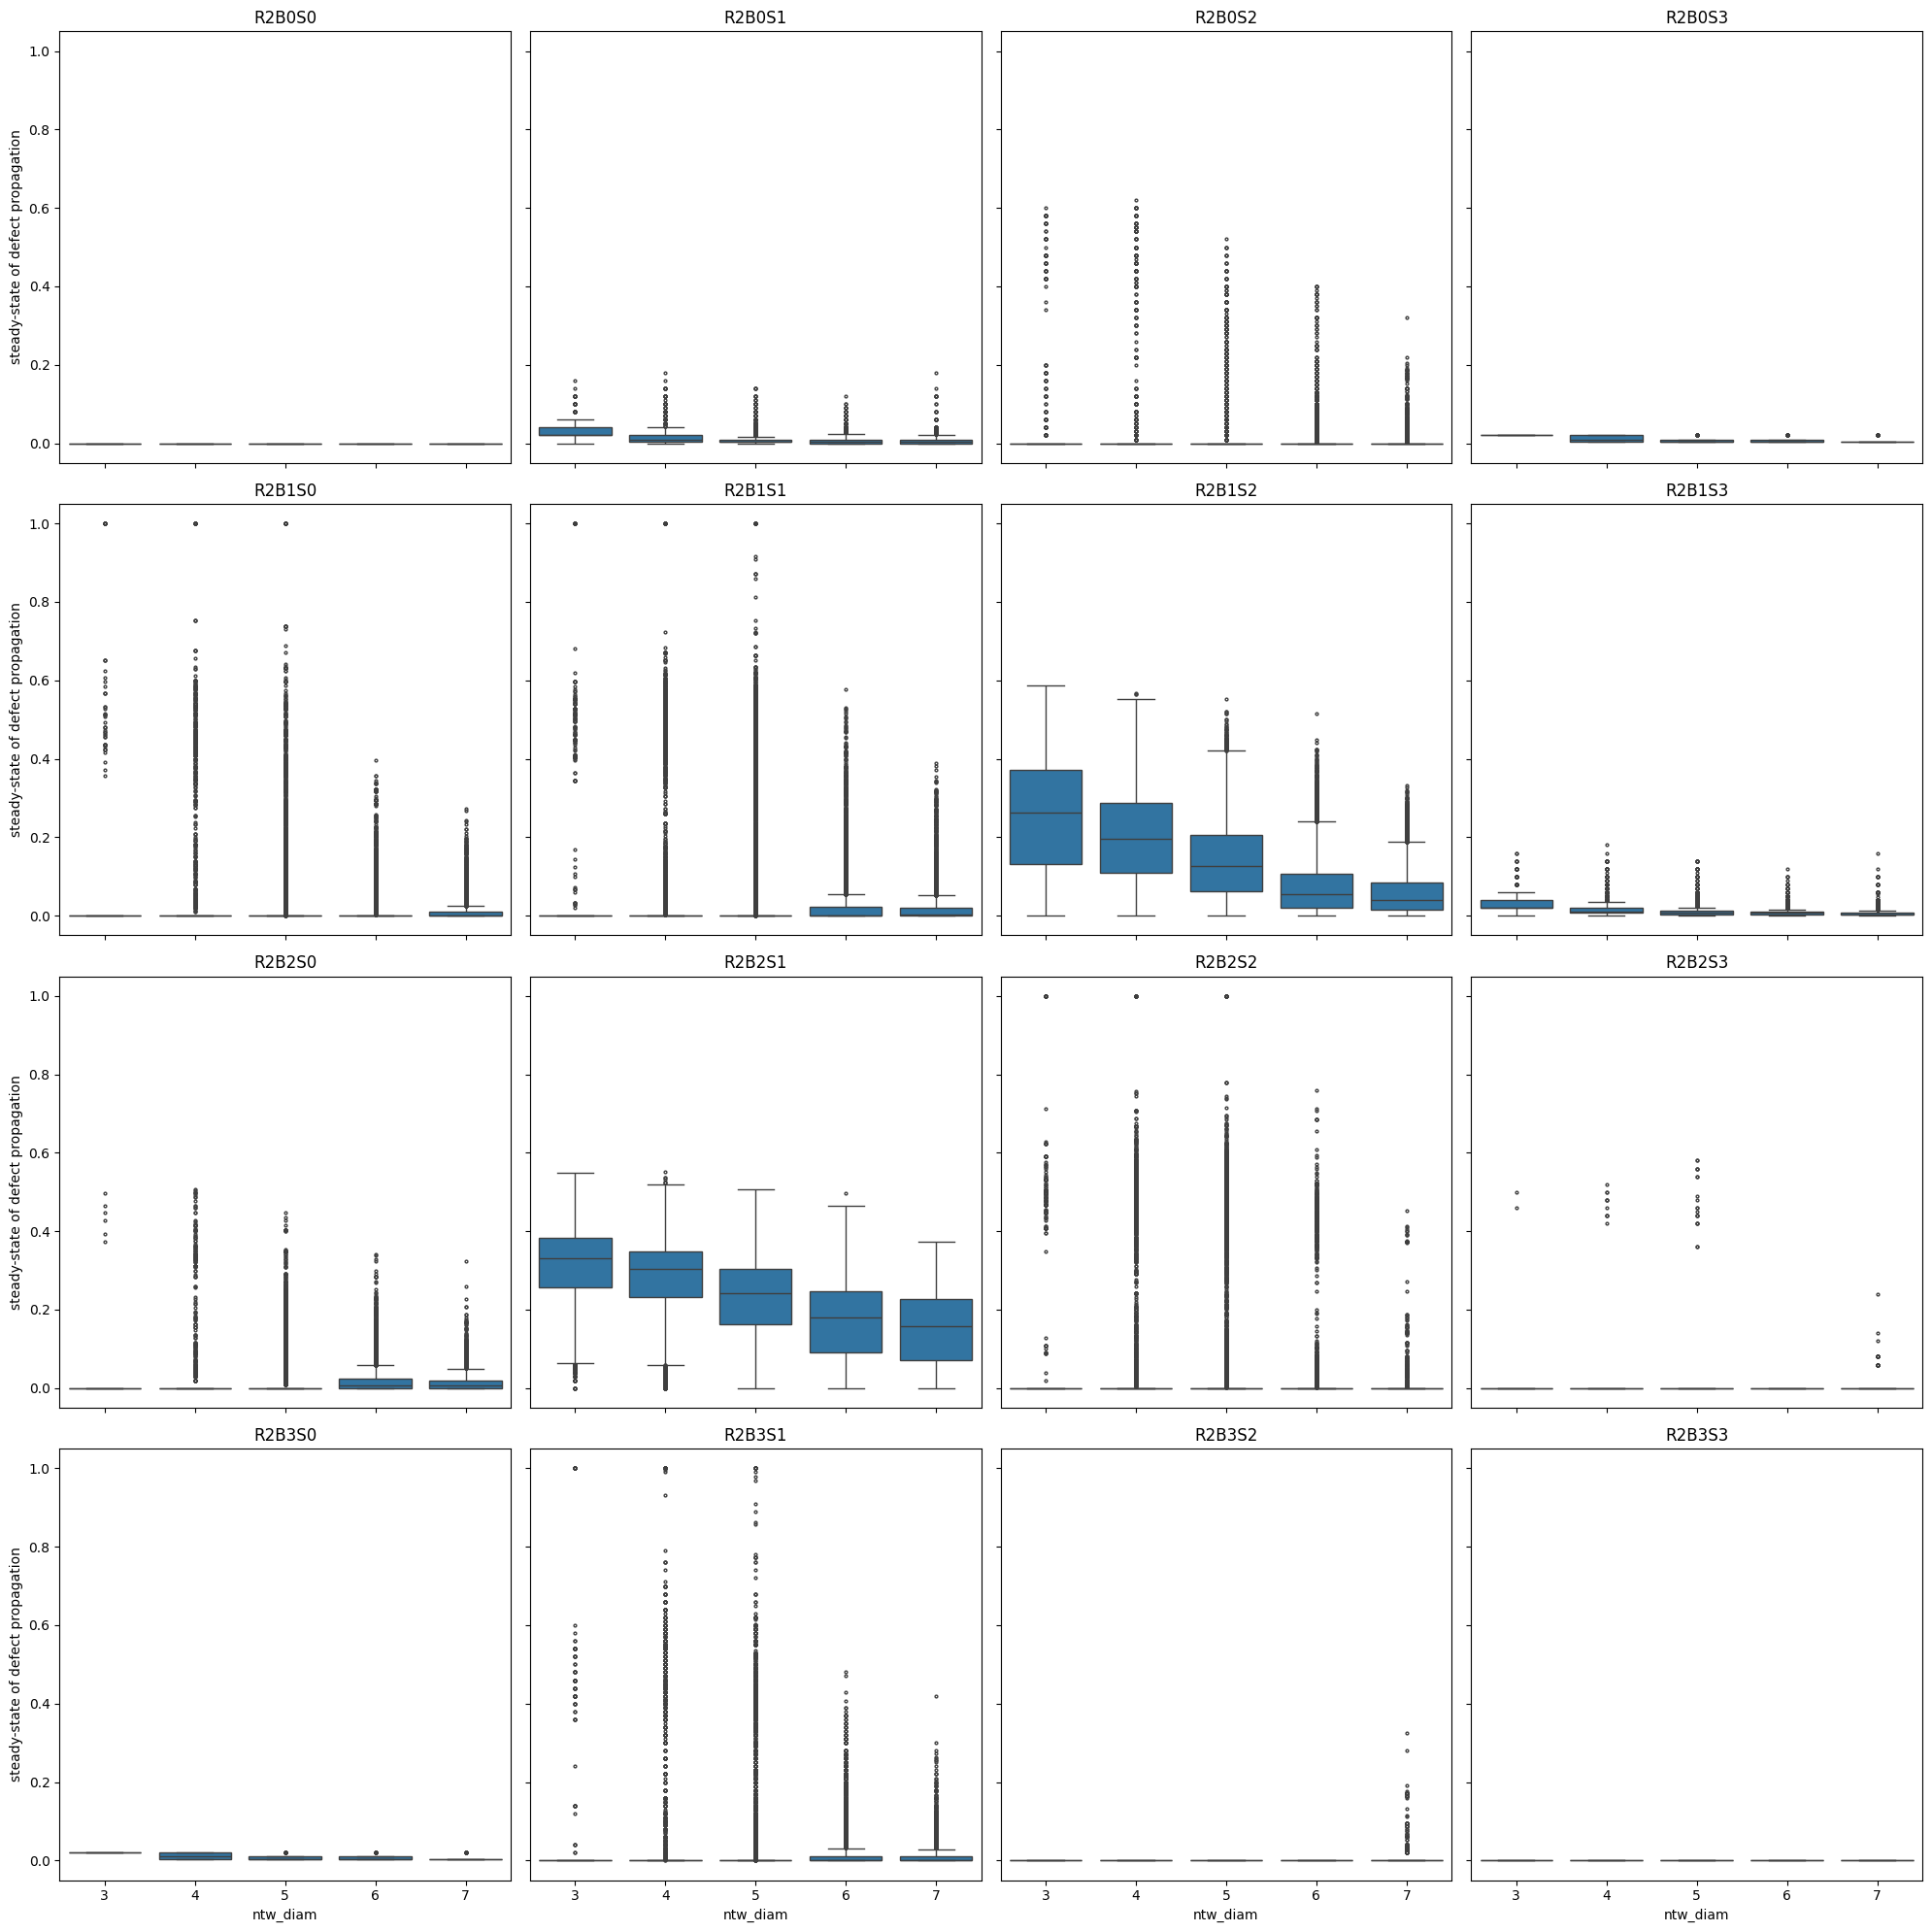

100%|██████████████████████████| 16/16 [00:04<00:00,  3.68it/s]


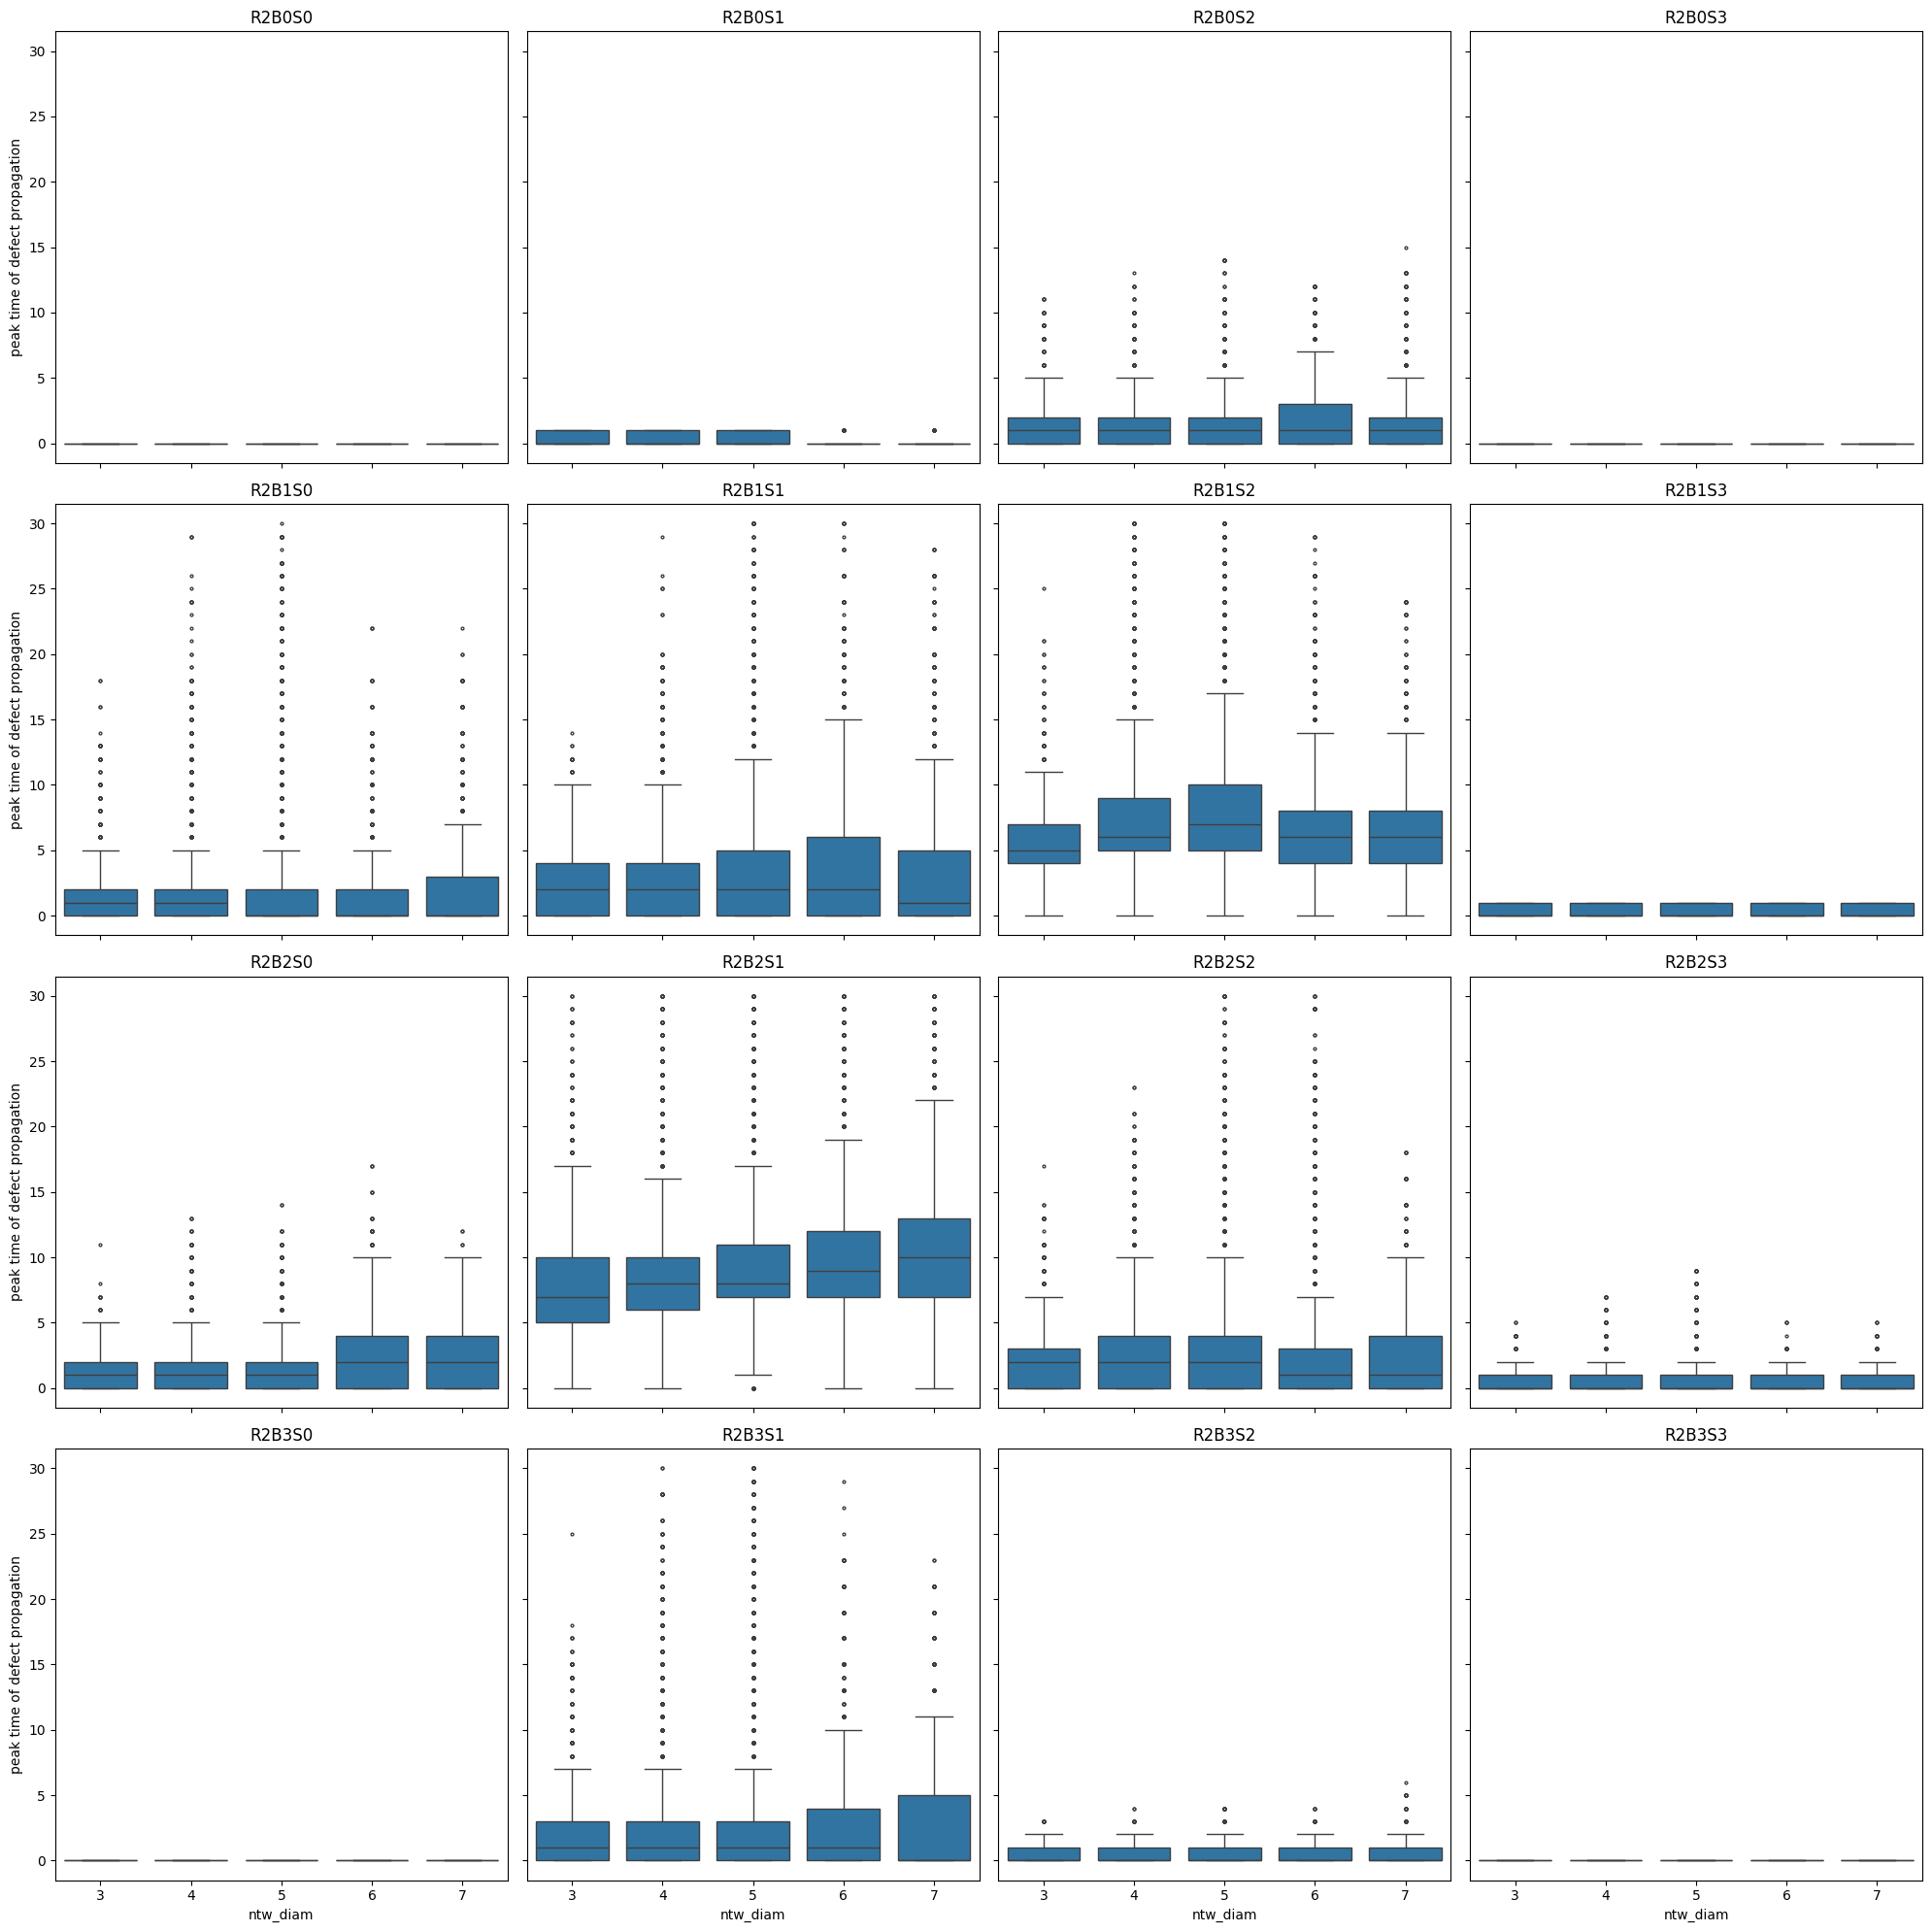

128429

In [161]:
col = 'ntw_diam'
mask = (df_trj['time_step']==0)
df, mask, values = representative_set(df_ntw, df_trj[mask], [col, 'tpeak', 'xdinf'], 10)
print(f'"{col}" : {mask.sum()} lines ({mask.mean()*100:.2f}%)')
print(values)

fig = plot_llna_family(df, x=col, y='xdinf', res=2, kind='box', fliersize=2)
fig.savefig(f'figures/steady-vs-{col}-r2.png')
fig.savefig(f'figures/steady-vs-{col}-r2.pdf')
del fig

fig = plot_llna_family(df, x=col, y='tpeak', res=2, kind='box', fliersize=2)
fig.savefig(f'figures/tpeak-vs-{col}-r2.png')
fig.savefig(f'figures/tpeak-vs-{col}-r2.pdf')
del fig

gc.collect()

"vtx_pagerank" : 159990 lines (99.99%)
[0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12]


100%|██████████████████████████| 16/16 [00:04<00:00,  3.34it/s]


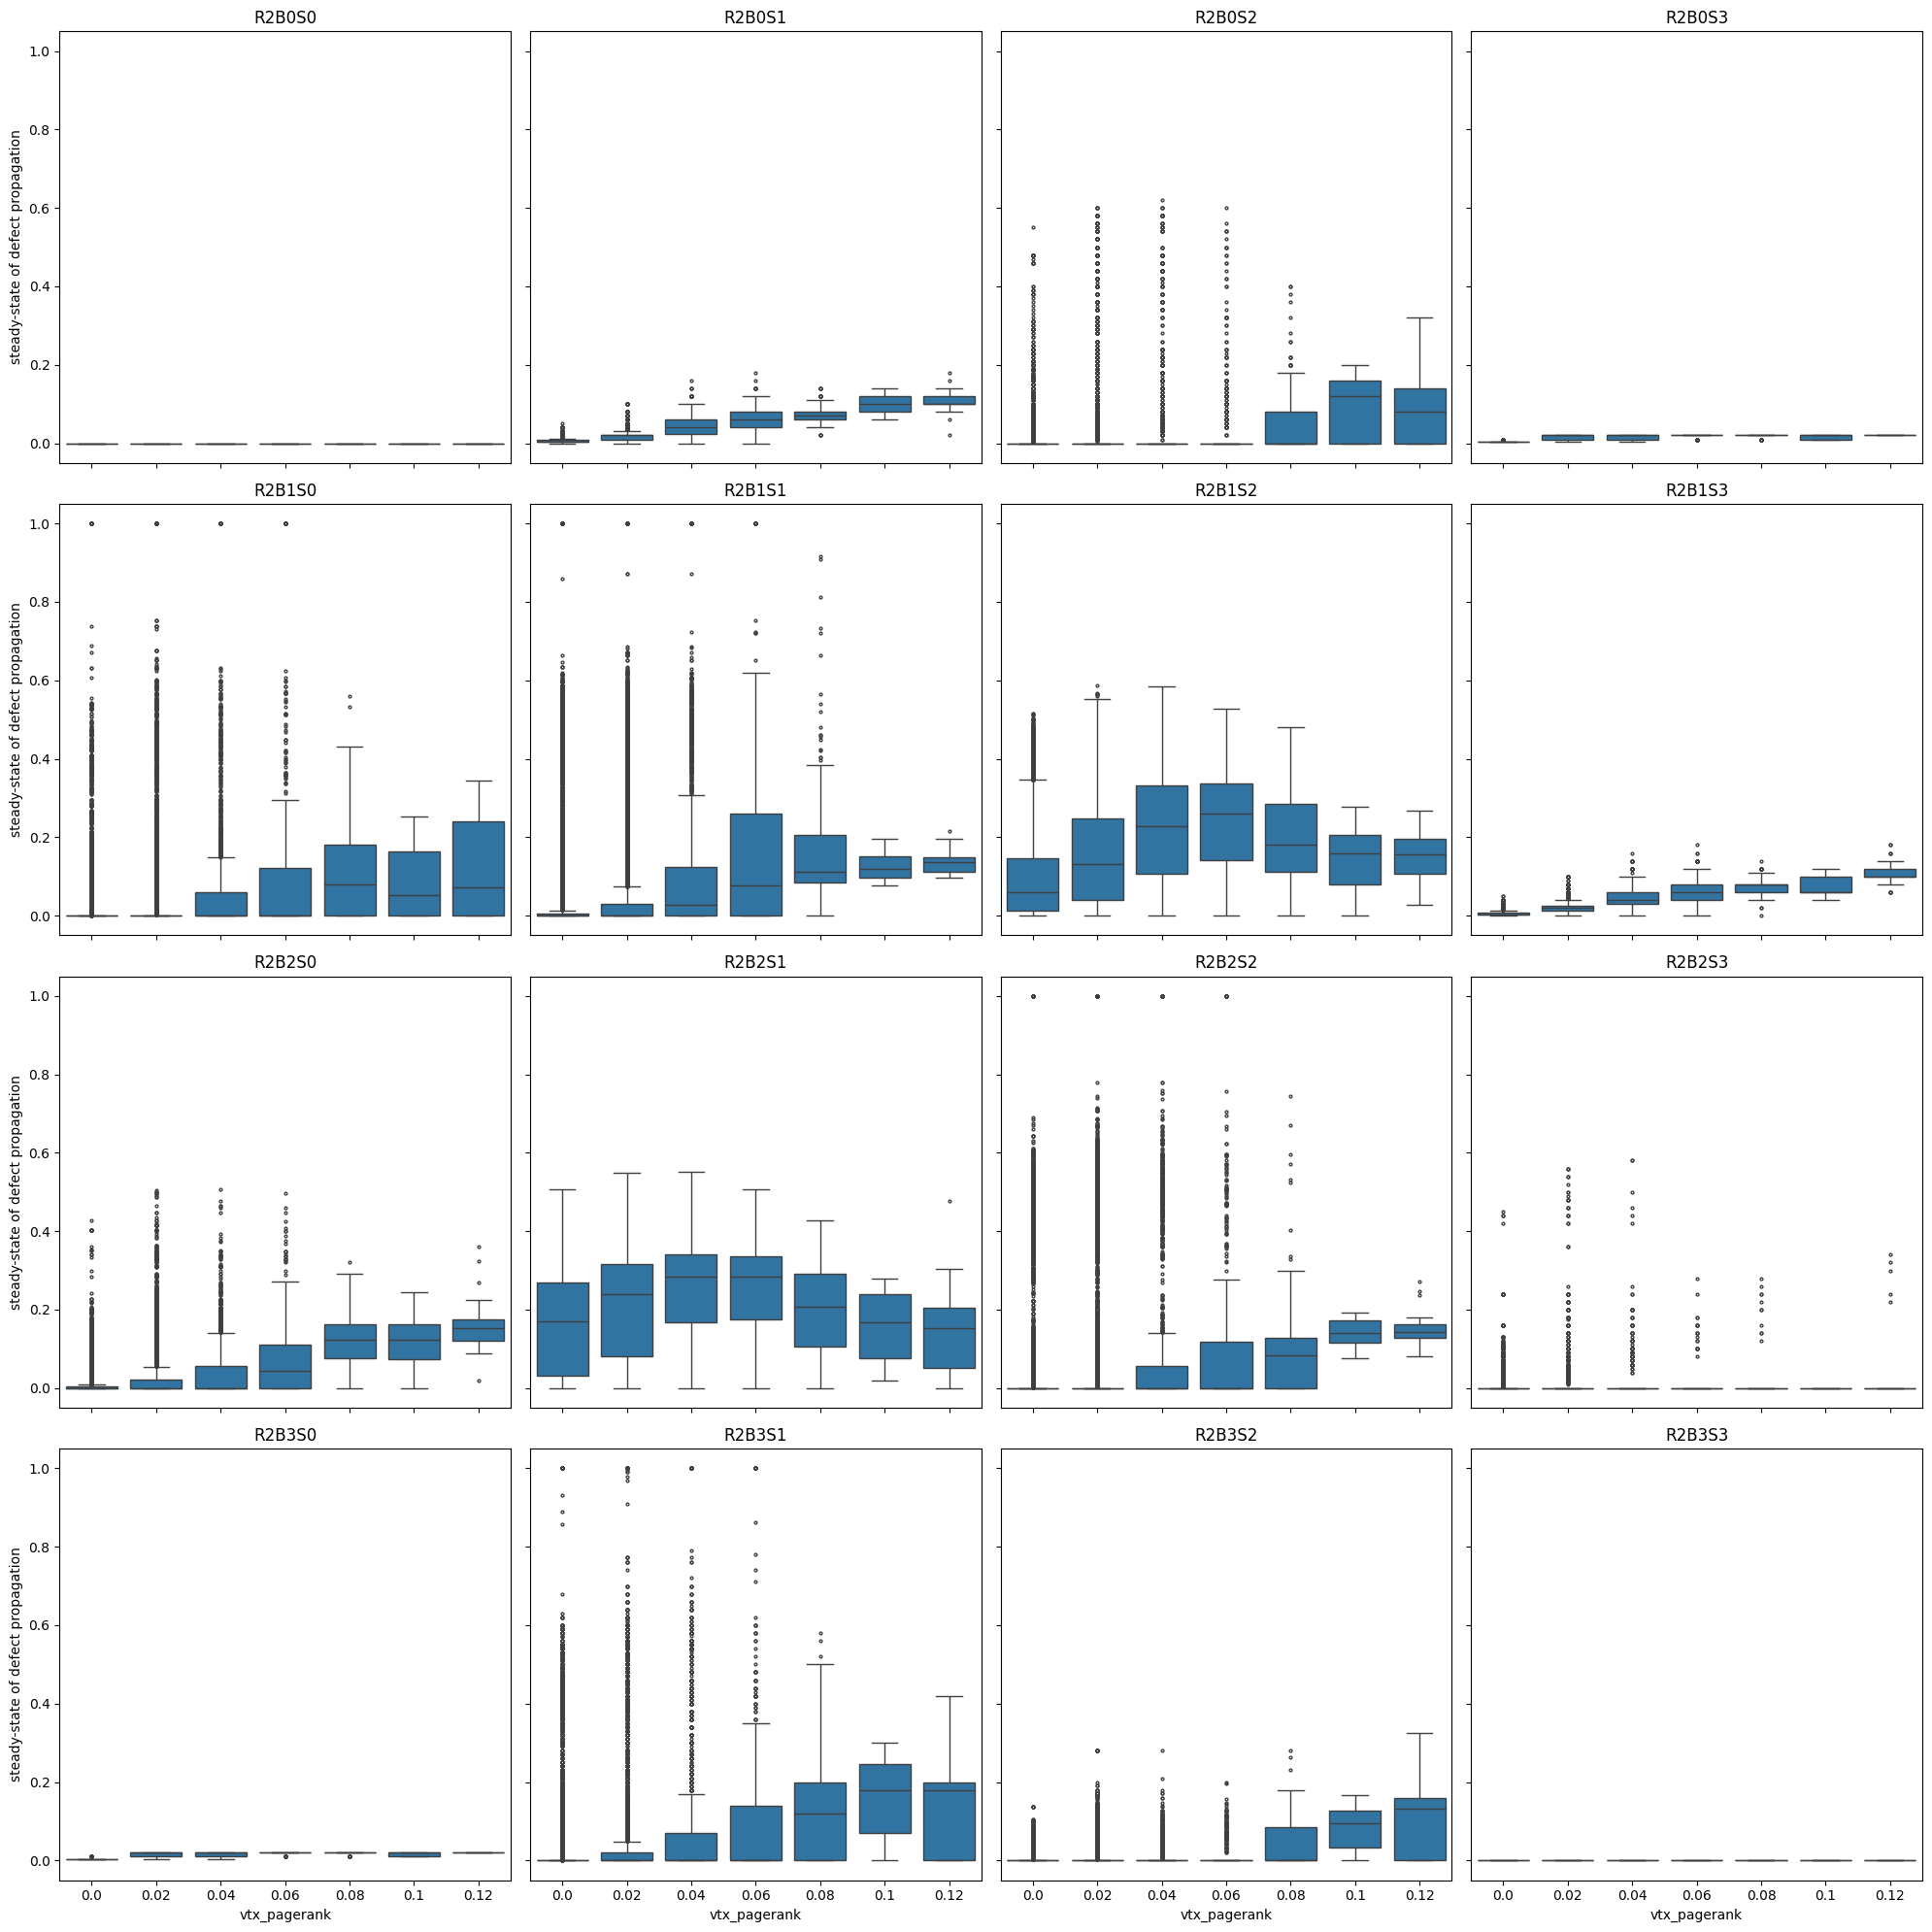

100%|██████████████████████████| 16/16 [00:05<00:00,  3.20it/s]


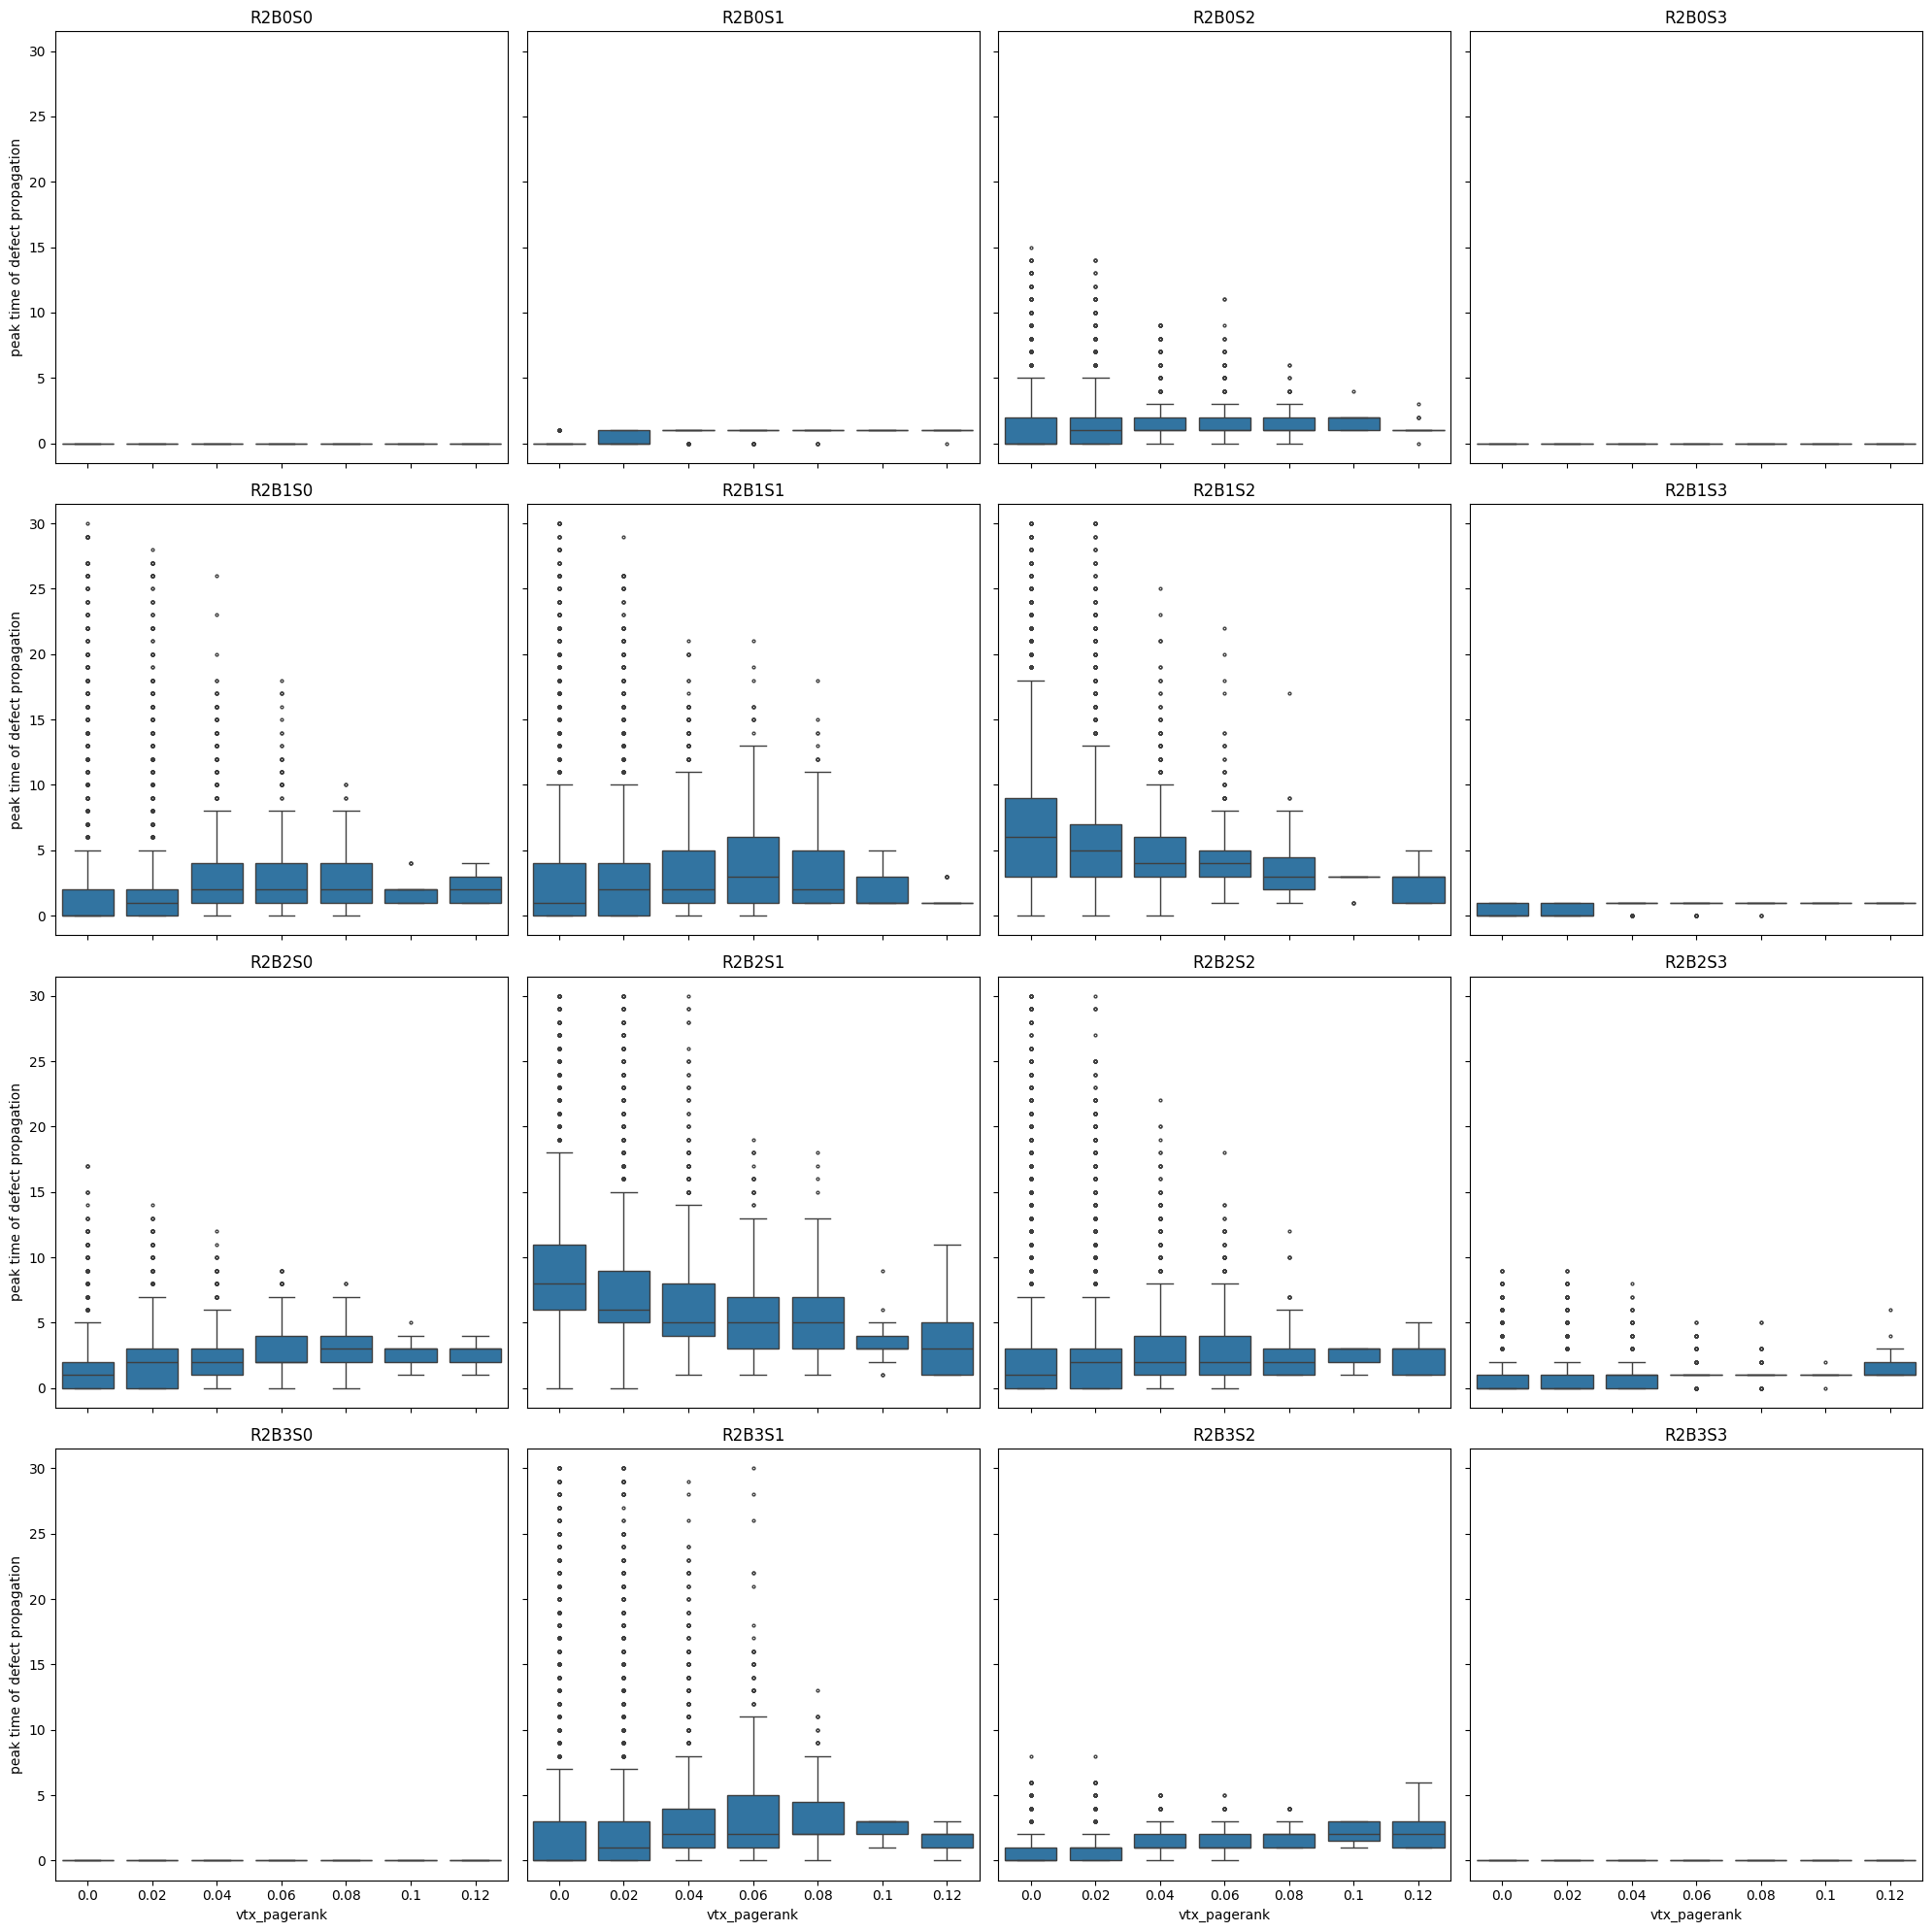

104890

In [157]:
col = 'vtx_pagerank'
mask = (df_trj['time_step']==0)
df, mask, values = representative_set(df_vtx, df_trj[mask], [col, 'tpeak', 'xdinf'], 10, base=0.02)
print(f'"{col}" : {mask.sum()} lines ({mask.mean()*100:.2f}%)')
print(values)

fig = plot_llna_family(df, x=col, y='xdinf', res=2, kind='box', fliersize=2)
fig.savefig(f'figures/steady-vs-{col}-r2.png')
fig.savefig(f'figures/steady-vs-{col}-r2.pdf')
gc.collect()

fig = plot_llna_family(df, x=col, y='tpeak', res=2, kind='box', fliersize=2)
fig.savefig(f'figures/tpeak-vs-{col}-r2.png')
fig.savefig(f'figures/tpeak-vs-{col}-r2.pdf')
gc.collect()

# 2) Lyapunov Exponent

In [2]:
# `defect_freq="multi"` refers to unitary disturbs along multiple time steps
dataset2 = TEPsDataset(path='../data/teps', rule='R2B1S2', defect_freq='multi', transform=np.array)

100%|████████████████████████████████████████| 150/150 [00:00<00:00, 383.97it/s]


In [3]:
# shape = [num_inits, num_scenarios, time_steps, num_nodes]
# num_scenarios = 1 (original) + N unitary defects (one per node)
dataset[0].shape

(1, 101, 51, 100)

In [4]:
init_conf = 0
X_all = dataset[50][init_conf]
Xo = X_all[0]        # original trajectory
Xp = X_all[1:]       # perturbed trajectories
Xo.shape, Xp.shape

((51, 100), (100, 51, 100))

In [5]:
# the delta at t=0 is the identity
# it will also be the identity for other time steps 
# if dealing with multiple perturbations on time
Xd = np.abs(Xp - Xo) # abs. difference (delta)
Xd[:,0,:]

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]])

In [6]:
# it will also be the identity for other time steps 
# if dealing with multiple perturbations on time
Xd[:,2,:]

array([[1, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 1, 0, ..., 0, 0, 1]])

In [7]:
Jt = ((Xp + Xo) % 2).transpose(1, 0, 2)
Jt.shape

(51, 100, 100)

In [8]:
# summing along the time axis is possible to get a notion
# of the size of the tangent vector at each time step
J_sum = Jt.sum((1,2))
J_sum

array([100, 273, 304, 234, 247, 181, 184, 181, 184, 181, 184, 181, 184,
       181, 184, 181, 184, 181, 184, 181, 184, 181, 184, 181, 184, 181,
       184, 181, 184, 181, 184, 181, 184, 181, 184, 181, 184, 181, 184,
       181, 184, 181, 184, 181, 184, 181, 184, 181, 184, 181, 184])

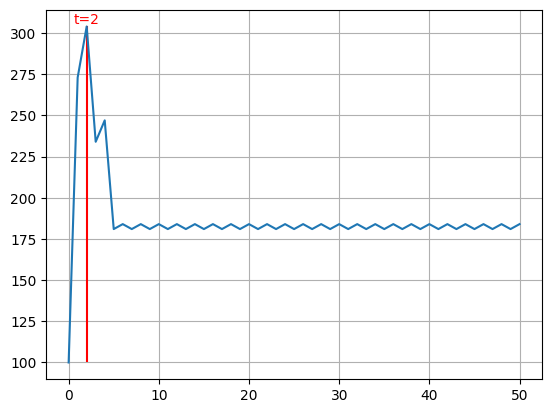

In [9]:
(x, ymin, ymax) = (J_sum.argmax(), J_sum.min(), J_sum.max())
plt.vlines(x, ymin, ymax, color='r')
plt.plot(J_sum)
plt.text(x, ymax+2, f't={x.item()}', ha='center', color='r')
plt.grid()

In [10]:
Jt.shape

(51, 100, 100)

In [11]:
J_all = []
for X_all in dataset:
    X_all = X_all[init_conf]
    Xo = X_all[0]
    Xp = X_all[1:]
    Jt = ((Xo + Xp) % 2).transpose(1, 0, 2)
    J_all.append(Jt)
J_all = np.stack(J_all, 0, dtype=np.float64)
J_all.shape

(150, 51, 100, 100)

In [12]:
J_sum = J_all.sum((-1,-2)) 
J_sum.shape

(150, 51)

In [13]:
J_avg = J_sum.mean(0)
J_std = J_sum.std(0)

(x_peak, y_min, y_max) = (J_avg.argmax(), J_avg.min(), J_avg.max())

x_time = np.arange(J_sum.shape[-1])
y_lower = J_avg - J_std
y_upper = J_avg + J_std

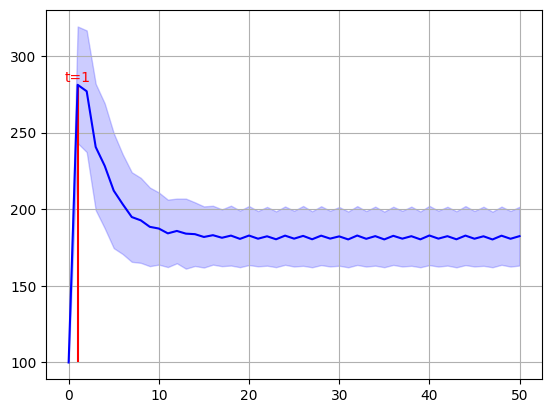

In [14]:
plt.vlines(x_peak, y_min, y_max, color='r')
plt.text(x_peak, y_max+2, f't={x_peak.item()}', ha='center', color='r')

plt.plot(x_time, J_avg, color='b')
plt.fill_between(x_time, y_lower, y_upper, color='b', alpha=0.2)

plt.grid()
plt.show()

In [15]:
T, _, N = Jt.shape
Y0 = np.eye(N)
Yt = [ Y0 ]

for J_tau in Jt:
    Yt.append( np.matmul(J_tau, Yt[-1]) )

Yt = np.stack(Yt, 0)
Yt.shape

(52, 100, 100)

In [16]:
Lt = [ lyapunov_spectrum(Y, t) for t, Y in enumerate(Yt[1:], 1) ]
Lt = np.stack(Lt, 0)
Lt.shape

(51, 100)

In [17]:
X = np.tile(np.arange(1, T+1), (N, 1)).T
X.shape

(51, 100)

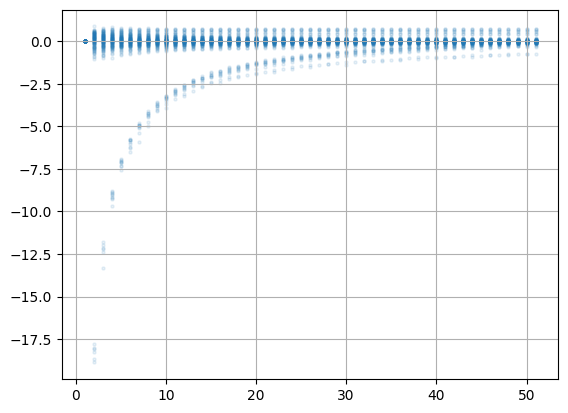

In [18]:
plt.scatter(X, Lt, s=5, alpha=5/T)
plt.grid()

In [19]:
from tqdm import tqdm

In [20]:
J_all.shape

(150, 51, 100, 100)

In [21]:
L_all = []
for J_net in tqdm(J_all, ncols=80):
    T, _, N = J_net.shape
    L = []
    Y = np.eye(N, dtype=np.float64)
    for t, Jt in enumerate(J_net, 0):
        Y = np.matmul(Jt, Y)
        L.append( lyapunov_spectrum(Y, t+1) )
    L_all.append(np.stack(L, 0))
#L_all = np.stack(L_all, -1)
L_all = np.concatenate(L_all, -1)
L_all.shape

100%|█████████████████████████████████████████| 150/150 [00:23<00:00,  6.51it/s]


(51, 15000)

In [22]:
X = np.tile(np.arange(1, L_all.shape[0]+1), (L_all.shape[-1], 1)).T
X.shape

(51, 15000)

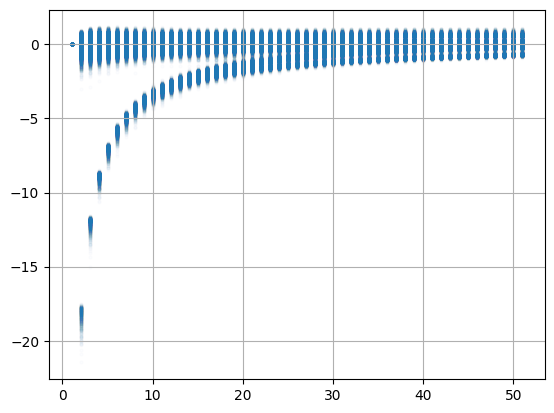

In [23]:
plt.scatter(X, L_all, s=5, alpha=1e-2)
plt.grid()